In [263]:
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [264]:
# construct winning expectancy dataframe
# if the win exp is unavailable, set as -1
# each row should be inning, top/bot(0/0.5), outs, base runners (a three value list), win ep from -5 to 5
we_df = pd.DataFrame(columns=["condition", "base_runners"] + list(range(-5, 6)))
with open("win_exp_table.txt", "r") as f:
    for line in f:
        row = line.strip().split("\t")

        if row[0] == "Inn": # pass
            continue
            
        # get info
        inning = int(row[0])
        top_bot = row[1]
        outs = int(row[2])
        base_runners = row[3]

        # get prob
        if inning == 1 and top_bot == "Top":
            win_ep_lst = row[4: ] + [-1, -1, -1, -1, -1]
        elif inning == 9 and top_bot == "Bottom":
            win_ep_lst = row[4: ] + [-1, -1, -1, -1, -1]
        else:
            win_ep_lst = row[4: ]

        # change top bot format
        if top_bot == "Top":
            top_bot = 0
        else:
            top_bot = 0.5
        
        # change base runners format
        if base_runners == "Empty":
            base_runners = (0, 0, 0)
        if base_runners == "1B only":
            base_runners = (1, 0, 0)
        if base_runners == "2B only":
            base_runners = (0, 1, 0)
        if base_runners == "1B & 2B":
            base_runners = (1, 1, 0)
        if base_runners == "3B only":
            base_runners = (0, 0, 1)
        if base_runners == "1B & 3B":
            base_runners = (1, 0, 1)
        if base_runners == "2B & 3B":
            base_runners = (0, 1, 1)
        if base_runners == "Loaded":
            base_runners = (1, 1, 1)

        # create condition [inning, top/bot, outs]
        condition = (inning, top_bot, outs)

        # add to dataframe
        we_df.loc[len(we_df)] = [condition, base_runners] + win_ep_lst

In [265]:
from scipy.interpolate import PchipInterpolator
import numpy as np

def build_we_splines(we_df):
    """
    Build WE spline family with safe monotone exponential tails.
    Returns:
        we_splines[(inning, topbot, outs)][(1B,2B,3B)] = f(sd)
    """

    we_splines = {}
    score_diffs = np.arange(-5, 6)

    for _, row in we_df.iterrows():

        condition = row["condition"]
        base_state = row["base_runners"]

        # -----------------------
        # Extract valid data
        # -----------------------
        y = np.array([row[i] for i in score_diffs], dtype=float)
        mask = y >= 0
        x_valid = score_diffs[mask]
        y_valid = y[mask]

        # Build raw monotone spline
        f_raw = PchipInterpolator(x_valid, y_valid, extrapolate=True)

        # -----------------------
        # Endpoint values
        # -----------------------
        xL, xR = x_valid[0], x_valid[-1]
        fL, fR = y_valid[0], y_valid[-1]

        # -----------------------
        # Endpoint derivatives
        # PCHIP may give negative or zero derivative at right end.
        # Must enforce monotonic WE curve.
        # -----------------------
        dL = float(f_raw.derivative()(xL))
        dR = float(f_raw.derivative()(xR))

        # Fix left derivative (should be >= 0 in practice)
        if dL <= 0:
            # fallback: positive slope based on neighbor
            dL = (y_valid[1] - y_valid[0]) / (x_valid[1] - x_valid[0])
            dL = max(dL, 1e-4)

        # Fix right derivative: MUST be positive so WE approaches 1
        if dR <= 0:
            # fallback derivative based on last two points
            dR = (y_valid[-1] - y_valid[-2]) / (x_valid[-1] - x_valid[-2])
            dR = max(dR, 1e-4)

        # Now compute tail parameters
        k_left = dL / fL                  # ensures smooth match on left
        k_right = dR / (1 - fR)           # ensures smooth match on right

        # -----------------------
        # Build final function
        # -----------------------
        def make_f(f_raw, xL, xR, fL, fR, k_left, k_right):
            def f(sd):
                sd = np.asarray(sd, float)

                out = np.zeros_like(sd)

                # Masks
                left = sd < xL
                right = sd > xR
                mid = (~left) & (~right)

                # Left exponential tail -> approaches 0
                out[left] = fL * np.exp(k_left * (sd[left] - xL))

                # Middle region (PCHIP)
                out[mid] = f_raw(sd[mid])

                # Right exponential tail -> approaches 1
                out[right] = 1 - (1 - fR) * np.exp(k_right * (xR - sd[right]))

                # Clip for numerical safety
                return np.clip(out, 0, 1)

            return f

        f = make_f(f_raw, xL, xR, fL, fR, k_left, k_right)

        # Store in dictionary
        if condition not in we_splines:
            we_splines[condition] = {}
        we_splines[condition][base_state] = f

    return we_splines


In [266]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_we_spline(we_splines, we_df, condition):
    """
    Plot the WE spline and original points with seaborn lines.
    Score diff limited to [-10, 10].
    X-axis shows integer ticks spaced every 2 units.
    """

    if condition not in we_splines:
        raise ValueError(f"Condition {condition} not in spline dictionary")

    inning, topbot, outs = condition

    # --------------------------------------
    # X DOMAIN RULES
    # --------------------------------------
    if (inning == 1 and topbot == 0) or (inning == 9 and topbot == 0.5):
        xs = np.linspace(-10, 0, 300)
    else:
        xs = np.linspace(-10, 10, 400)

    # --------------------------------------
    # PLOT SETUP
    # --------------------------------------
    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    palette = sns.color_palette("tab10", n_colors=len(we_splines[condition]))

    # --------------------------------------
    # PLOT SPLINES + SCATTER POINTS
    # --------------------------------------
    for (base_state, f), color in zip(we_splines[condition].items(), palette):

        ys = f(xs)

        sns.lineplot(
            x=xs,
            y=ys,
            label=str(base_state),
            color=color,
            linewidth=2.2,
            alpha=0.85
        )

        # original data
        df_sub = we_df[(we_df["condition"] == condition) &
                       (we_df["base_runners"] == base_state)]

        orig_x = np.arange(-5, 6)
        orig_y = np.array([df_sub.iloc[0][i] for i in range(-5, 6)], float)
        mask = orig_y >= 0

        # remove invalid score_diff > 0 for top1/bot9
        if (inning == 1 and topbot == 0) or (inning == 9 and topbot == 0.5):
            valid_x = orig_x[(orig_x <= 0) & mask]
            valid_y = orig_y[(orig_x <= 0) & mask]
        else:
            valid_x = orig_x[mask]
            valid_y = orig_y[mask]

        plt.scatter(
            valid_x,
            valid_y,
            s=60,
            color=color,
            edgecolor='black',
            zorder=10
        )

    # --------------------------------------
    # TITLES & AXIS SETUP
    # --------------------------------------
    title_half = "Top" if topbot == 0 else "Bot"
    plt.title(
        f"WE Splines — Inning {inning}, {title_half}, Outs = {outs}",
        fontsize=16
    )

    plt.xlabel("Score Difference (Home - Away)", fontsize=14)
    plt.ylabel("Win Expectancy", fontsize=14)

    # integer ticks every 2 units
    plt.xticks(np.arange(int(xs.min()), int(xs.max()) + 1, 2))

    plt.ylim(-0.05, 1.05)
    plt.xlim(xs.min(), xs.max())

    plt.legend(
        title="Base Runners\n(1B,2B,3B)",
        fontsize=10,
        title_fontsize=11,
        bbox_to_anchor=(1.04, 1),
        borderaxespad=0
    )

    plt.tight_layout()
    plt.show()

/var/folders/r1/fdb0tbq57qj3ww3lz_lh0xf00000gn/T/ipykernel_61382/3441776616.py:58: RuntimeWarning: divide by zero encountered in scalar divide
  k_right = dR / (1 - fR)           # ensures smooth match on right
/var/folders/r1/fdb0tbq57qj3ww3lz_lh0xf00000gn/T/ipykernel_61382/3441776616.py:57: RuntimeWarning: divide by zero encountered in scalar divide
  k_left = dL / fL                  # ensures smooth match on left


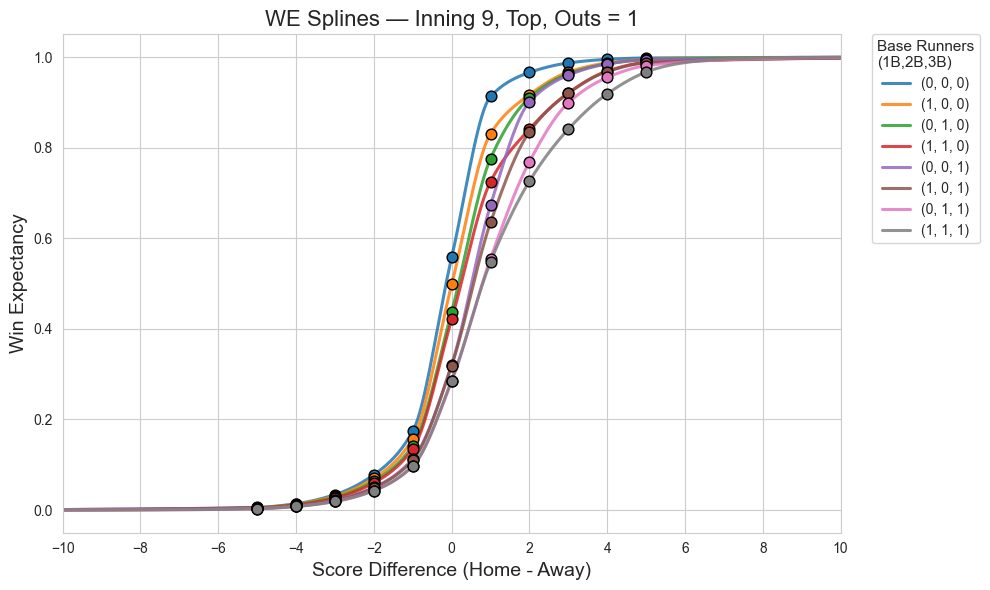

In [267]:
we_splines = build_we_splines(we_df)

condition = (9, 0, 1)  # inning 3, top half, 1 out
plot_we_spline(we_splines, we_df, condition)


In [268]:
def get_WE(condition, base_runners, score_diff, win=-1, we_splines=we_splines):
    """
    Return the Win Expectancy (WE) for a given:
    - condition = (inning, topbot, outs)
    - base_runners = (1B,2B,3B)
    - score_diff = home_score - away_score.
    
    Uses the final spline with asymptotic tails.
    """

    # the game is done
    if win == 0:
        return 0
    if win == 1:
        return 1

    # Check condition exists
    if condition not in we_splines:
        raise ValueError(f"Condition {condition} not in spline dictionary.")
    
    # entering extra inning
    if condition[0] > 9: # extra inning
        return 0.52
    
    cond_dict = we_splines[condition]

    # Check base-runner state exists
    if base_runners not in cond_dict:
        raise ValueError(f"Base runner state {base_runners} not valid for condition {condition}.")

    # Retrieve spline
    f = cond_dict[base_runners]

    # Evaluate at score_diff
    return float(f(score_diff))

In [269]:
# load pa level data
df = pd.read_parquet("PA_level_data.parquet")
df.head()

,at_bat_number,pitch_number,game_pk,home_team,away_team,inning,post_inning,inning_topbot,post_inning_topbot,outs,post_outs,pitcher,pitcher_name,batter,batter_name,on_3b,on_2b,on_1b,post_on_3b,post_on_2b,post_on_1b,home_score,post_home_score,away_score,post_away_score,bat_score,post_bat_score,RBI,score_diff,post_score_diff
284506,4,1,776135,LAA,HOU,1,1,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,1,1,1,0,1,0,0,0,1,0,1,1,0,-1
237535,9,6,776135,LAA,HOU,1,1,0.5,0.5,1,1,621121,lance mccullers,545361,mike trout,0,0,0,0,0,0,0,1,1,1,0,1,1,-1,0
284432,38,5,776135,LAA,HOU,5,5,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,0,0,0,0,0,1,1,1,2,1,2,1,0,-1
284423,41,3,776135,LAA,HOU,5,5,0.0,0.0,2,2,691951,sam aldegheri,602104,ramón urías,0,1,0,0,0,0,1,1,2,4,2,4,2,-1,-3
284422,42,1,776135,LAA,HOU,5,5,0.0,0.0,2,2,641401,connor brogdon,694728,brice matthews,0,0,0,0,0,0,1,1,4,5,4,5,1,-3,-4


In [270]:
# add condition, base runners, and post columns
df["condition"] = tuple(zip(df["inning"], df["inning_topbot"], df["outs"]))
df["post_condition"] = tuple(zip(df["post_inning"], df["post_inning_topbot"], df["post_outs"]))
df["base_runners"] = tuple(zip(df["on_1b"], df["on_2b"], df["on_3b"]))
df["post_base_runners"] = tuple(zip(df["post_on_1b"], df["post_on_2b"], df["post_on_3b"]))

In [271]:
# we only care 9 innings
df = df[df["inning"] <= 9]

# add result
result_lst = []
for index, row in df.iterrows():
    post_outs = row["post_outs"]
    if post_outs != -1:
        result_lst.append(-1)
    else:
        if row["post_score_diff"] > 0:
            result_lst.append(1)
        elif row["post_score_diff"] < 0:
            result_lst.append(0)
        else:
            result_lst.append(-1)

df["result"] = result_lst

In [272]:
df.head()

,at_bat_number,pitch_number,game_pk,home_team,away_team,inning,post_inning,inning_topbot,post_inning_topbot,outs,post_outs,pitcher,pitcher_name,batter,batter_name,on_3b,on_2b,on_1b,post_on_3b,post_on_2b,post_on_1b,home_score,post_home_score,away_score,post_away_score,bat_score,post_bat_score,RBI,score_diff,post_score_diff,condition,post_condition,base_runners,post_base_runners,result
284506,4,1,776135,LAA,HOU,1,1,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,1,1,1,0,1,0,0,0,1,0,1,1,0,-1,"(1, 0.0, 1)","(1, 0.0, 1)","(1, 1, 0)","(1, 0, 1)",-1
237535,9,6,776135,LAA,HOU,1,1,0.5,0.5,1,1,621121,lance mccullers,545361,mike trout,0,0,0,0,0,0,0,1,1,1,0,1,1,-1,0,"(1, 0.5, 1)","(1, 0.5, 1)","(0, 0, 0)","(0, 0, 0)",-1
284432,38,5,776135,LAA,HOU,5,5,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,0,0,0,0,0,1,1,1,2,1,2,1,0,-1,"(5, 0.0, 1)","(5, 0.0, 1)","(0, 0, 0)","(0, 0, 0)",-1
284423,41,3,776135,LAA,HOU,5,5,0.0,0.0,2,2,691951,sam aldegheri,602104,ramón urías,0,1,0,0,0,0,1,1,2,4,2,4,2,-1,-3,"(5, 0.0, 2)","(5, 0.0, 2)","(0, 1, 0)","(0, 0, 0)",-1
284422,42,1,776135,LAA,HOU,5,5,0.0,0.0,2,2,641401,connor brogdon,694728,brice matthews,0,0,0,0,0,0,1,1,4,5,4,5,1,-3,-4,"(5, 0.0, 2)","(5, 0.0, 2)","(0, 0, 0)","(0, 0, 0)",-1


In [273]:
# apply win expectancy function
df["WE"] = df.apply(lambda row: get_WE(condition=row["condition"], base_runners=row["base_runners"], 
                                       score_diff=row["score_diff"]), axis=1)
df["WE_end"] = df.apply(lambda row: get_WE(condition=row["post_condition"], base_runners=row["post_base_runners"],
                                            score_diff=row["post_score_diff"], win=row["result"]), axis=1)

In [274]:
# change WE respect to hitting team not home team
df.loc[df["inning_topbot"] == 0, "WE"] = 1 - df["WE"]
df.loc[df["inning_topbot"] == 0, "WE_end"] = 1 - df["WE_end"]
df["delta_WE"] = df["WE_end"] - df["WE"]
df.head()

,at_bat_number,pitch_number,game_pk,home_team,away_team,inning,post_inning,inning_topbot,post_inning_topbot,outs,post_outs,pitcher,pitcher_name,batter,batter_name,on_3b,on_2b,on_1b,post_on_3b,post_on_2b,post_on_1b,home_score,post_home_score,away_score,post_away_score,bat_score,post_bat_score,RBI,score_diff,post_score_diff,condition,post_condition,base_runners,post_base_runners,result,WE,WE_end,delta_WE
284506,4,1,776135,LAA,HOU,1,1,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,1,1,1,0,1,0,0,0,1,0,1,1,0,-1,"(1, 0.0, 1)","(1, 0.0, 1)","(1, 1, 0)","(1, 0, 1)",-1,0.538,0.658,0.120
237535,9,6,776135,LAA,HOU,1,1,0.5,0.5,1,1,621121,lance mccullers,545361,mike trout,0,0,0,0,0,0,0,1,1,1,0,1,1,-1,0,"(1, 0.5, 1)","(1, 0.5, 1)","(0, 0, 0)","(0, 0, 0)",-1,0.419,0.526,0.107
284432,38,5,776135,LAA,HOU,5,5,0.0,0.0,1,1,691951,sam aldegheri,673237,yainer diaz,0,0,0,0,0,0,1,1,1,2,1,2,1,0,-1,"(5, 0.0, 1)","(5, 0.0, 1)","(0, 0, 0)","(0, 0, 0)",-1,0.470,0.621,0.151
284423,41,3,776135,LAA,HOU,5,5,0.0,0.0,2,2,691951,sam aldegheri,602104,ramón urías,0,1,0,0,0,0,1,1,2,4,2,4,2,-1,-3,"(5, 0.0, 2)","(5, 0.0, 2)","(0, 1, 0)","(0, 0, 0)",-1,0.630,0.826,0.196
284422,42,1,776135,LAA,HOU,5,5,0.0,0.0,2,2,641401,connor brogdon,694728,brice matthews,0,0,0,0,0,0,1,1,4,5,4,5,1,-3,-4,"(5, 0.0, 2)","(5, 0.0, 2)","(0, 0, 0)","(0, 0, 0)",-1,0.826,0.892,0.066


In [275]:
def beta_func(a, b, alpha):
    mu = (1 + a) / 2

    # domain of b is [a, 1]
    # correct sigma to fit domain
    sigma = min((mu - a) / 2, (1 - mu) / 2)

    # scaled normal-shaped value
    alpha = alpha + 1e-10 # prevent zero
    beta = (2 / alpha) * np.exp(-((b - mu) ** 2) / (2 * sigma ** 2))
    return beta

In [276]:
# compute two different ARBI1: sigmoid function with k = 4
df["alpha1"] = 2 / (1 + np.exp(-4 * df["delta_WE"]))
df["ARBI1"] = df["alpha1"] * df["RBI"]

# compute CRBI1
df["beta1"] = df.apply(lambda row: beta_func(row["delta_WE"], row["WE_end"], row["alpha1"]), axis=1)
df["CRBI1"] = df["ARBI1"] * df["beta1"]

In [277]:
# save df with result
result_df = df[["batter", "batter_name", "RBI", "ARBI1", "CRBI1", "delta_WE", "WE_end", "alpha1", "beta1"]]
result_df.head()

,batter,batter_name,RBI,ARBI1,CRBI1,delta_WE,WE_end,alpha1,beta1
284506,673237,yainer diaz,1,1.235496,1.811096,0.120,0.658,1.235496,1.465886
237535,545361,mike trout,1,1.210792,1.984884,0.107,0.526,1.210792,1.639327
284432,673237,yainer diaz,1,1.293142,1.95457,0.151,0.621,1.293142,1.511489
284423,602104,ramón urías,2,2.746166,2.102115,0.196,0.826,1.373083,0.765473
284422,694728,brice matthews,1,1.131239,0.613384,0.066,0.892,1.131239,0.542223


In [278]:
# save the data
result_df.to_parquet("data_with_result.parquet")